In [13]:
"""Analysis of reasoning token lengths for base model coding inference."""

import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

In [14]:
# --- configuration ---

FIGURES_DIR = Path("../../figures/01")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# pre-computed stats live here (generated by scripts/compute_stats.py)
OVERFLOW_DIR = Path("../../output/stats")

# datasets to analyse, grouped by domain.
# each entry: display label → (inference file stem, dataset jsonl path)
DATASETS: dict[str, dict[str, tuple[str, str]]] = {
    "code": {
        "evalplus": ("evalplus_greedy", "code/evalplus.jsonl"),
        "livecodebench": ("livecodebench_greedy", "code/livecodebench.jsonl"),
        "bigcodebench": ("bigcodebench_greedy", "code/bigcodebench.jsonl"),
        "cruxeval_i": ("cruxeval_i_greedy", "code/cruxeval_i.jsonl"),
        "cruxeval_o": ("cruxeval_o_greedy", "code/cruxeval_o.jsonl"),
    },
    "math": {
        "gsm8k": ("gsm8k_greedy", "math/gsm8k.jsonl"),
        "gpqa": ("gpqa_greedy", "math/gpqa.jsonl"),
    },
}

# base models: name → huggingface path + olmo_style flag.
# olmo_style=True means the chat template injects <think> automatically so a
# missing </think> in output indicates the response was truncated.
MODELS: dict[str, dict] = {
    "qwen3-8b": {
        "hf_path": "Qwen/Qwen3-8B",
        "olmo_style": False,
    },
    "olmo-3-7b-think": {
        "hf_path": "allenai/OLMo-3-7B-Think",
        "olmo_style": True,
    },
    "nemotron-7b": {
        "hf_path": "nvidia/OpenReasoning-Nemotron-7B",
        "olmo_style": False,
    },
    "code-nemotron-7b": {
        "hf_path": "nvidia/OpenCodeReasoning-Nemotron-7B",
        "olmo_style": False,
    },
}

# series define a (model, decoding strategy) combination.
# file_suffix is appended to each dataset's base file stem when loading files
# (e.g. suffix "_steer" turns "evalplus_greedy" → "evalplus_greedy_steer").
SERIES: dict[str, dict] = {
    "qwen3_greedy": {
        "label": "Qwen3-8B\n(greedy)",
        "model_key": "qwen3-8b",
        "file_suffix": "",
        "colour": "#2196F3",
    },
    "qwen3_steer": {
        "label": "Qwen3-8B\n(steer)",
        "model_key": "qwen3-8b",
        "file_suffix": "_steer",
        "colour": "#9C27B0",
    },
    "olmo_greedy": {
        "label": "OLMo3-7B\n(greedy)",
        "model_key": "olmo-3-7b-think",
        "file_suffix": "",
        "colour": "#FF9800",
    },
    "nemotron_greedy": {
        "label": "Nemotron-7B\n(greedy)",
        "model_key": "nemotron-7b",
        "file_suffix": "",
        "colour": "#E91E63",
    },
    "code_nemotron_greedy": {
        "label": "Code-Nemotron-7B\n(greedy)",
        "model_key": "code-nemotron-7b",
        "file_suffix": "",
        "colour": "#4CAF50",
    },
}

# human-readable subplot titles for each dataset
DATASET_DISPLAY_NAMES: dict[str, str] = {
    "evalplus": "EvalPlus (simple coding)",
    "livecodebench": "LiveCodeBench (complex coding)",
    "bigcodebench": "BigCodeBench (coding)",
    "cruxeval_i": "CRUXEval-I (input prediction)",
    "cruxeval_o": "CRUXEval-O (output prediction)",
    "gsm8k": "GSM8K (simple math)",
    "gpqa": "GPQA (expert Q&A)",
}

# colours used when group_by="model" — one colour per dataset for the violins
DATASET_COLOURS: dict[str, str] = {
    "evalplus": "#2196F3",
    "livecodebench": "#9C27B0",
    "bigcodebench": "#FF9800",
    "cruxeval_i": "#E91E63",
    "cruxeval_o": "#F44336",
    "gsm8k": "#009688",
    "gpqa": "#607D8B",
}

# max generation tokens used for all runs
MAX_TOKENS = 32768

In [15]:
def load_series_results(
    series_keys: list[str],
    datasets: dict[str, dict[str, tuple[str, str]]],
) -> dict[str, dict[str, dict[str, list]]]:
    """Load pre-computed overflow statistics from output/overflow/.

    Run scripts/compute_overflow_stats.py first to generate these files.
    Missing files are skipped with a warning.

    Returns a nested dict: series_key → ds_label → {token_counts, truncated, overflow, budget_pct, pass_at_1}.
    """
    # flatten all datasets across domains for iteration
    all_datasets: list[str] = [
        ds_label
        for domain_datasets in datasets.values()
        for ds_label in domain_datasets
    ]

    results: dict[str, dict[str, dict[str, list]]] = {}
    for series_key in series_keys:
        results[series_key] = {}
        for ds_label in all_datasets:
            stats_path = OVERFLOW_DIR / series_key / f"{ds_label}.json"
            if not stats_path.exists():
                print(
                    f"  [skip] missing {stats_path} "
                    f"— run scripts/compute_overflow_stats.py first"
                )
                continue

            with open(stats_path) as f:
                stats = json.load(f)

            results[series_key][ds_label] = {
                "token_counts": stats["token_counts"],
                "truncated": stats["truncated"],
                # older cache files may not have overflow; fall back to truncated
                "overflow": stats.get("overflow", stats["truncated"]),
                "budget_pct": stats["budget_pct"],
                "pass_at_1": stats["pass_at_1"],
            }

            n_trunc = sum(stats["truncated"])
            n_overflow = sum(stats.get("overflow", stats["truncated"]))
            counts = stats["token_counts"]
            pcts = stats["budget_pct"]
            pass_at_1 = stats["pass_at_1"]
            print(
                f"  {series_key} / {ds_label}: "
                f"n={len(counts)}, "
                f"median={int(np.median(counts)):,} tokens, "
                f"median budget={np.median(pcts):.1f}%, "
                f"pass@1={100 * pass_at_1:.1f}%, "
                f"reasoning overflow={n_trunc} ({100 * n_trunc / len(counts):.1f}%), "
                f"general overflow={n_overflow} ({100 * n_overflow / len(counts):.1f}%)"
            )

    return results


# load all series upfront — individual plot calls will select the subset they need
print("loading results...")
all_results = load_series_results(
    series_keys=list(SERIES.keys()),
    datasets=DATASETS,
)

loading results...
  qwen3_greedy / evalplus: n=542, median=2,054 tokens, median budget=6.3%, pass@1=64.4%, reasoning overflow=40 (7.4%), general overflow=41 (7.6%)
  qwen3_greedy / livecodebench: n=342, median=16,035 tokens, median budget=50.0%, pass@1=37.4%, reasoning overflow=92 (26.9%), general overflow=93 (27.2%)
  qwen3_greedy / bigcodebench: n=1140, median=4,569 tokens, median budget=14.0%, pass@1=19.9%, reasoning overflow=219 (19.2%), general overflow=220 (19.3%)
  qwen3_greedy / cruxeval_i: n=800, median=2,470 tokens, median budget=7.6%, pass@1=85.9%, reasoning overflow=68 (8.5%), general overflow=68 (8.5%)
  qwen3_greedy / cruxeval_o: n=800, median=793 tokens, median budget=2.4%, pass@1=88.1%, reasoning overflow=27 (3.4%), general overflow=27 (3.4%)
  qwen3_greedy / gsm8k: n=1319, median=1,455 tokens, median budget=4.4%, pass@1=95.1%, reasoning overflow=9 (0.7%), general overflow=9 (0.7%)
  qwen3_greedy / gpqa: n=448, median=8,487 tokens, median budget=26.1%, pass@1=42.6%, re

In [16]:
def _draw_violin_axes(
    ax: plt.Axes,
    data_per_violin: list[list],
    labels: list[str],
    colours: list[str],
    annotations: list[str],
    title: str,
    ylabel: str,
    hline: float | None,
    ylim: tuple | None,
    yformatter,
) -> None:
    """Draw violin plots for one subplot, with per-violin annotations.

    Positions violins at integer x positions, colours each by its entry in
    colours, and writes annotation text below the axis for each violin.
    """
    positions = list(range(1, len(data_per_violin) + 1))

    parts = ax.violinplot(
        data_per_violin,
        positions=positions,
        showmedians=True,
        showextrema=True,
    )

    for pc, colour in zip(parts["bodies"], colours):
        pc.set_facecolor(colour)
        pc.set_alpha(0.6)

    # write stats below the x-axis for each violin; -0.08 keeps them close but not cramped
    for colour, x_pos, annotation in zip(colours, positions, annotations):
        ax.text(
            x_pos,
            -0.08,
            annotation,
            ha="center",
            va="top",
            fontsize=11,
            fontweight="bold",
            color=colour,
            transform=ax.get_xaxis_transform(),
        )

    if hline is not None:
        ax.axhline(hline, color="red", linestyle="--", linewidth=1.2)

    ax.set_xticks(positions)
    ax.set_xticklabels(
        labels,
        rotation=0,
        ha="center",
        fontsize=10,
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=11)

    if ylim is not None:
        ax.set_ylim(ylim)
    else:
        ax.set_ylim(bottom=0)

    if yformatter is not None:
        ax.yaxis.set_major_formatter(yformatter)

    ax.tick_params(axis="y", labelsize=10)
    ax.grid(axis="y", alpha=0.3)


def _build_plot(
    series_keys: list[str],
    loaded_results: dict,
    datasets: dict,
    group_by: str,
    get_data: callable,
    get_annotation: callable,
    ylabel: str,
    hline: float | None,
    ylim: tuple | None,
    yformatter,
    save_path: Path,
) -> None:
    """Build and save a violin plot figure, stacked vertically.

    group_by="dataset": one subplot per dataset, one violin per series/model.
    group_by="model":   one subplot per series/model, one violin per dataset.
    """
    # flatten all dataset labels in order
    all_ds_labels: list[str] = [
        ds_label for domain_ds in datasets.values() for ds_label in domain_ds
    ]

    if group_by == "dataset":
        # outer loop = datasets; each subplot has one violin per series
        n_rows = len(all_ds_labels)
        # width scales with number of violins (series) per subplot
        col_width = max(6, len(series_keys) * 2.5)
        row_height = max(4, len(series_keys) * 1.0)
    elif group_by == "model":
        # outer loop = series/models; each subplot has one violin per dataset
        n_rows = len(series_keys)
        # width scales with number of violins (datasets) per subplot
        col_width = max(6, len(all_ds_labels) * 2.5)
        row_height = max(4, len(all_ds_labels) * 1.0)
    else:
        raise ValueError(f"group_by must be 'dataset' or 'model', got {group_by!r}")

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=1,
        figsize=(col_width, row_height * n_rows),
        sharey=True,
        squeeze=False,
    )

    if group_by == "dataset":
        for row_idx, ds_label in enumerate(all_ds_labels):
            ax = axes[row_idx][0]
            active_labels: list[str] = []
            active_colours: list[str] = []
            active_data: list[list] = []
            active_annotations: list[str] = []

            for series_key in series_keys:
                ds_results = loaded_results.get(series_key, {}).get(ds_label)
                if ds_results is None:
                    continue
                active_labels.append(SERIES[series_key]["label"])
                active_colours.append(SERIES[series_key]["colour"])
                active_data.append(get_data(ds_results))
                active_annotations.append(get_annotation(ds_results))

            _draw_violin_axes(
                ax=ax,
                data_per_violin=active_data,
                labels=active_labels,
                colours=active_colours,
                annotations=active_annotations,
                title=DATASET_DISPLAY_NAMES[ds_label],
                ylabel=ylabel,
                hline=hline,
                ylim=ylim,
                yformatter=yformatter,
            )

    else:  # group_by == "model"
        for row_idx, series_key in enumerate(series_keys):
            ax = axes[row_idx][0]
            active_labels = []
            active_colours = []
            active_data = []
            active_annotations = []

            for ds_label in all_ds_labels:
                ds_results = loaded_results.get(series_key, {}).get(ds_label)
                if ds_results is None:
                    continue
                active_labels.append(DATASET_DISPLAY_NAMES[ds_label])
                active_colours.append(DATASET_COLOURS[ds_label])
                active_data.append(get_data(ds_results))
                active_annotations.append(get_annotation(ds_results))

            _draw_violin_axes(
                ax=ax,
                data_per_violin=active_data,
                labels=active_labels,
                colours=active_colours,
                annotations=active_annotations,
                title=SERIES[series_key]["label"].replace("\n", " "),
                ylabel=ylabel,
                hline=hline,
                ylim=ylim,
                yformatter=yformatter,
            )

    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"saved {save_path}")
    plt.show()


def _make_annotation(ds_results: dict, median_str: str) -> str:
    """Build the per-violin annotation string showing median, both overflow rates, and pass@1."""
    truncated = ds_results["truncated"]
    overflow = ds_results["overflow"]
    pass_at_1 = ds_results["pass_at_1"]
    pct_trunc = 100 * sum(truncated) / len(truncated)
    pct_overflow = 100 * sum(overflow) / len(overflow)
    return (
        f"Median = {median_str}\n"
        f"Reasoning →∞ = {pct_trunc:.1f}%\n"
        f"General →∞ = {pct_overflow:.1f}%\n"
        f"Pass@1 = {100 * pass_at_1:.1f}%"
    )


def plot_token_lengths(
    series_keys: list[str],
    loaded_results: dict,
    datasets: dict,
    save_path: Path,
    group_by: str = "dataset",
    max_tokens: int = MAX_TOKENS,
) -> None:
    """Plot violin distributions of raw reasoning token counts.

    One subplot per group (dataset or model), stacked vertically.  A red
    dashed line marks the generation cap (max_tokens).  group_by controls
    whether subplots group results by dataset (violin per series) or by model
    (violin per dataset).
    """

    def get_data(ds_results: dict) -> list[int]:
        return ds_results["token_counts"]

    def get_annotation(ds_results: dict) -> str:
        counts = ds_results["token_counts"]
        return _make_annotation(
            ds_results=ds_results,
            median_str=f"{int(np.median(counts)):,}",
        )

    _build_plot(
        series_keys=series_keys,
        loaded_results=loaded_results,
        datasets=datasets,
        group_by=group_by,
        get_data=get_data,
        get_annotation=get_annotation,
        ylabel="Reasoning tokens",
        hline=max_tokens,
        ylim=None,
        yformatter=mticker.FuncFormatter(lambda x, _: f"{int(x):,}"),
        save_path=save_path,
    )


def plot_budget_pct(
    series_keys: list[str],
    loaded_results: dict,
    datasets: dict,
    save_path: Path,
    group_by: str = "dataset",
) -> None:
    """Plot violin distributions of reasoning as % of available token budget.

    Truncated responses are pinned at 100% so they visually hit the budget
    ceiling.  One subplot per group, stacked vertically.  group_by controls
    whether subplots group results by dataset (violin per series) or by model
    (violin per dataset).
    """

    def get_data(ds_results: dict) -> list[float]:
        return ds_results["budget_pct"]

    def get_annotation(ds_results: dict) -> str:
        pcts = ds_results["budget_pct"]
        return _make_annotation(
            ds_results=ds_results,
            median_str=f"{np.median(pcts):.1f}%",
        )

    _build_plot(
        series_keys=series_keys,
        loaded_results=loaded_results,
        datasets=datasets,
        group_by=group_by,
        get_data=get_data,
        get_annotation=get_annotation,
        ylabel="% of token budget used for reasoning",
        hline=100,
        ylim=(0, 105),
        yformatter=mticker.PercentFormatter(),
        save_path=save_path,
    )

saved ../../figures/overflow/01/base_reasoning_token_length.png


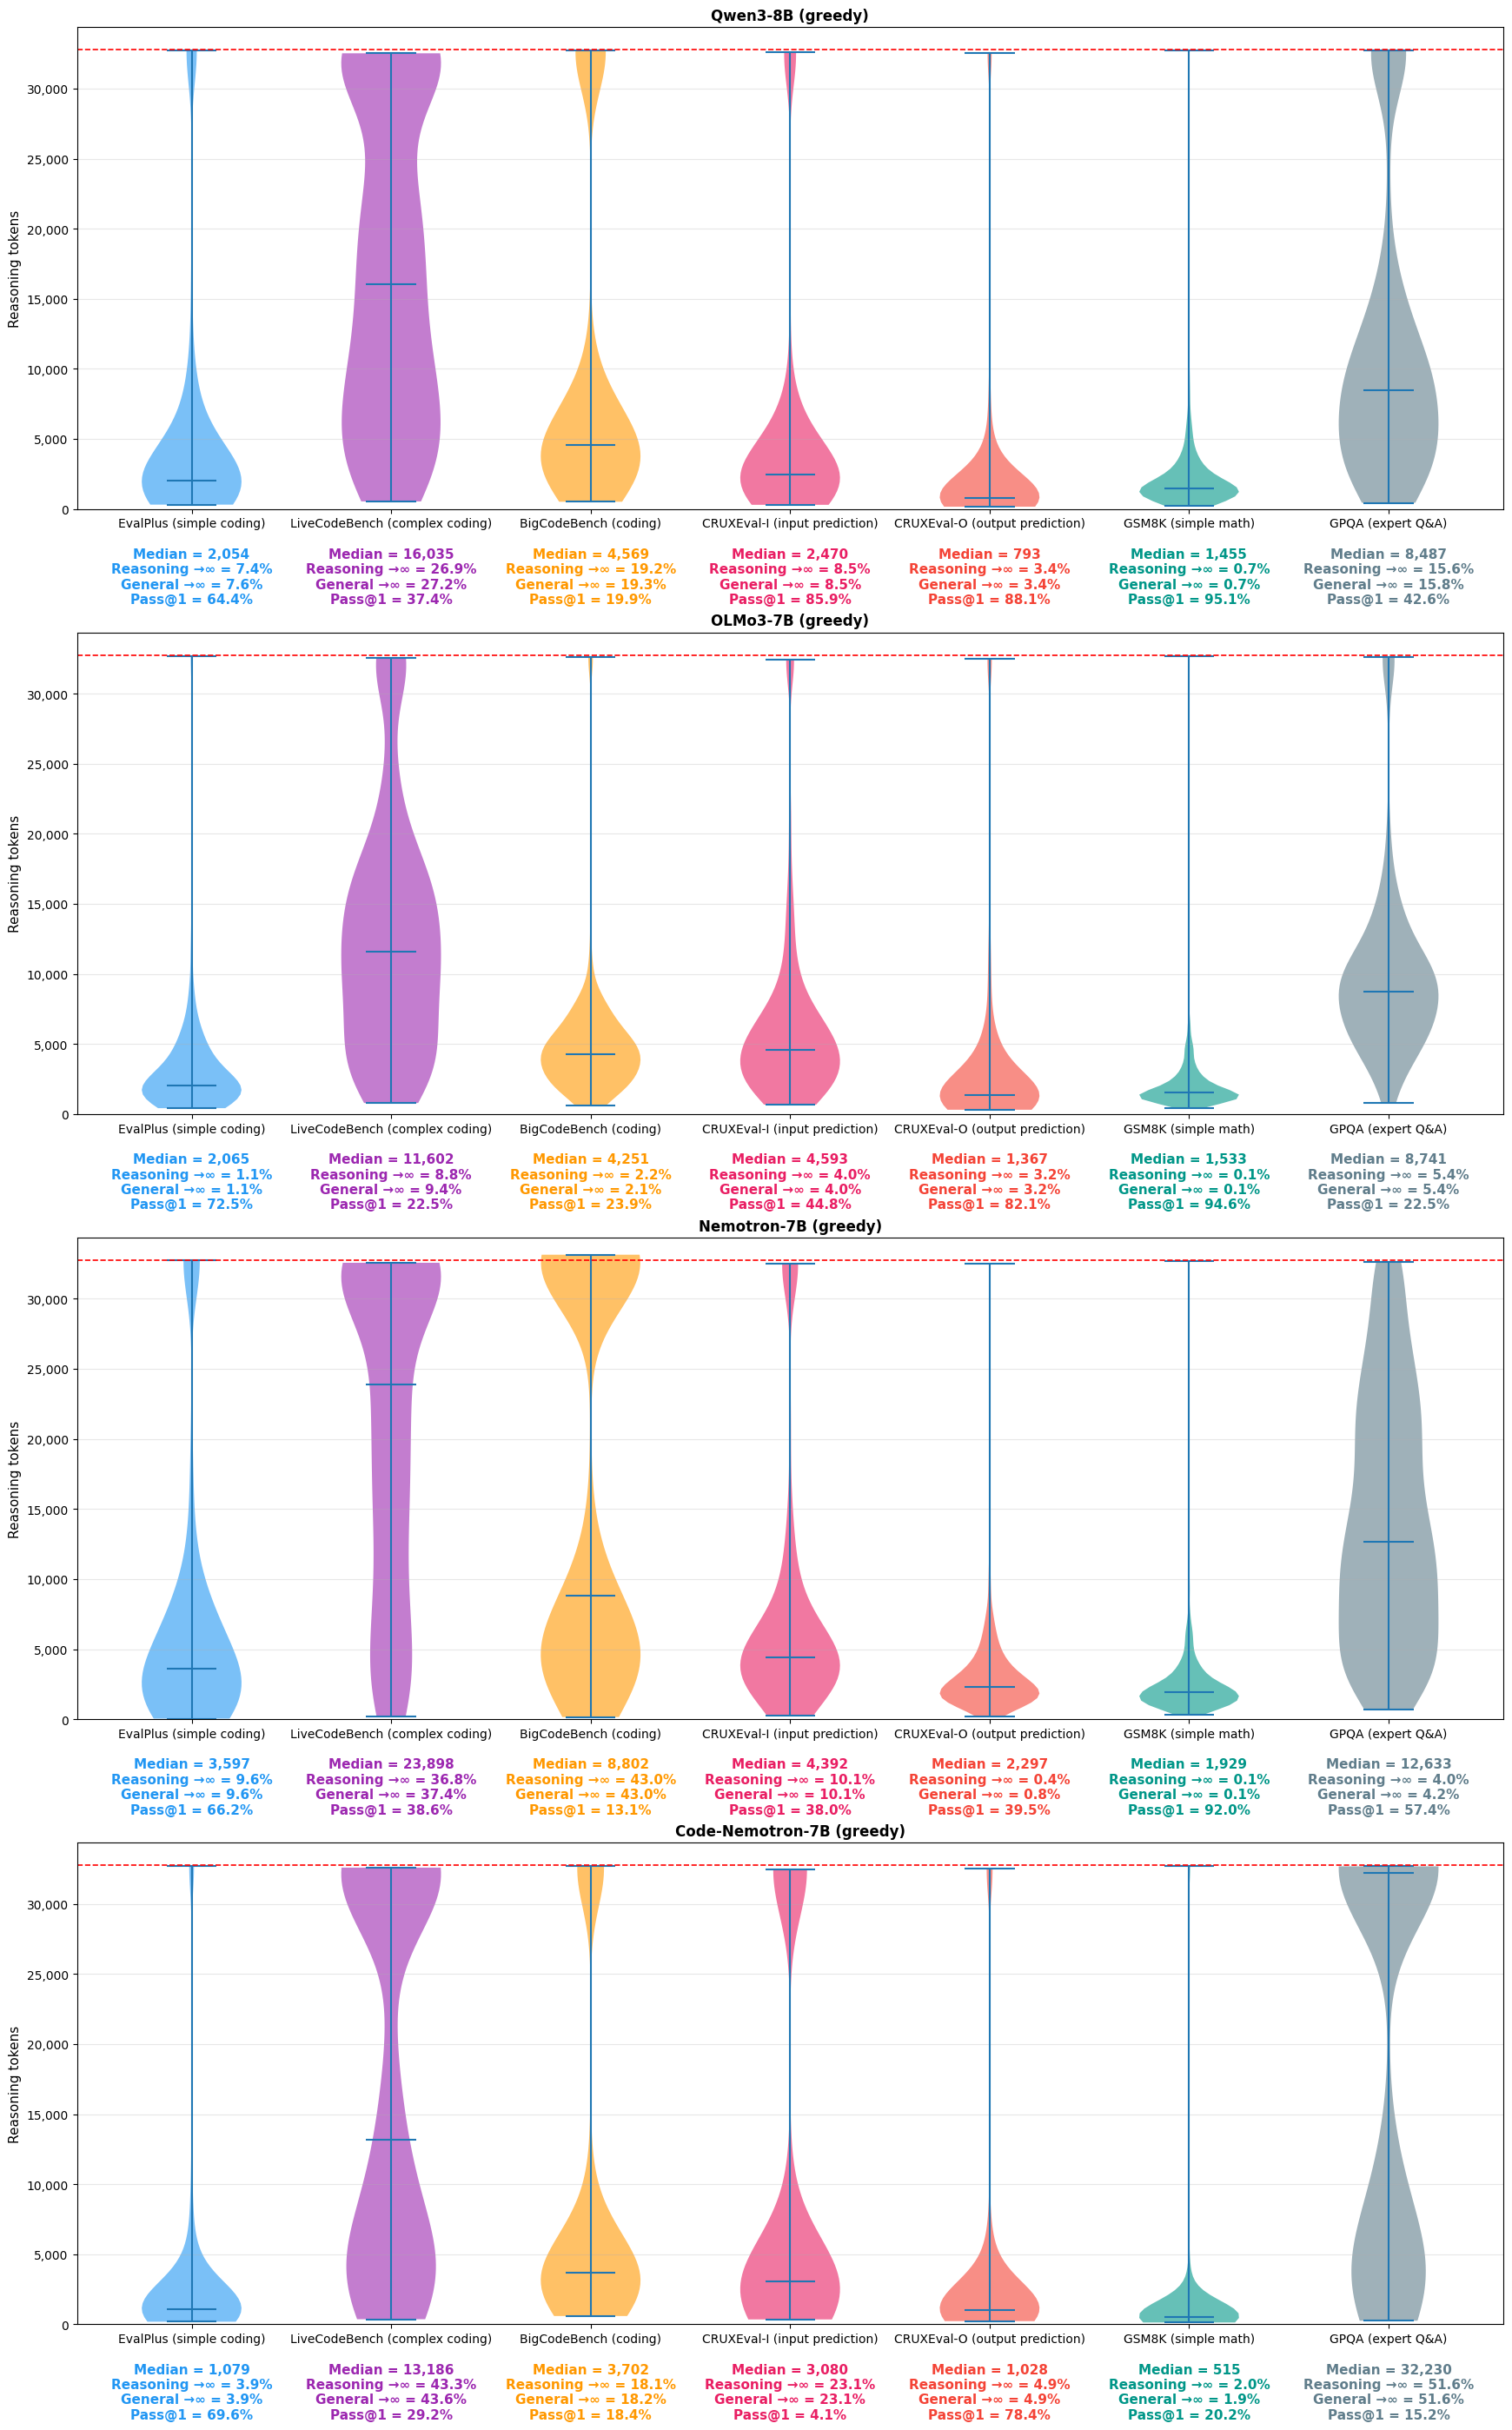

saved ../../figures/overflow/01/base_reasoning_budget_pct.png


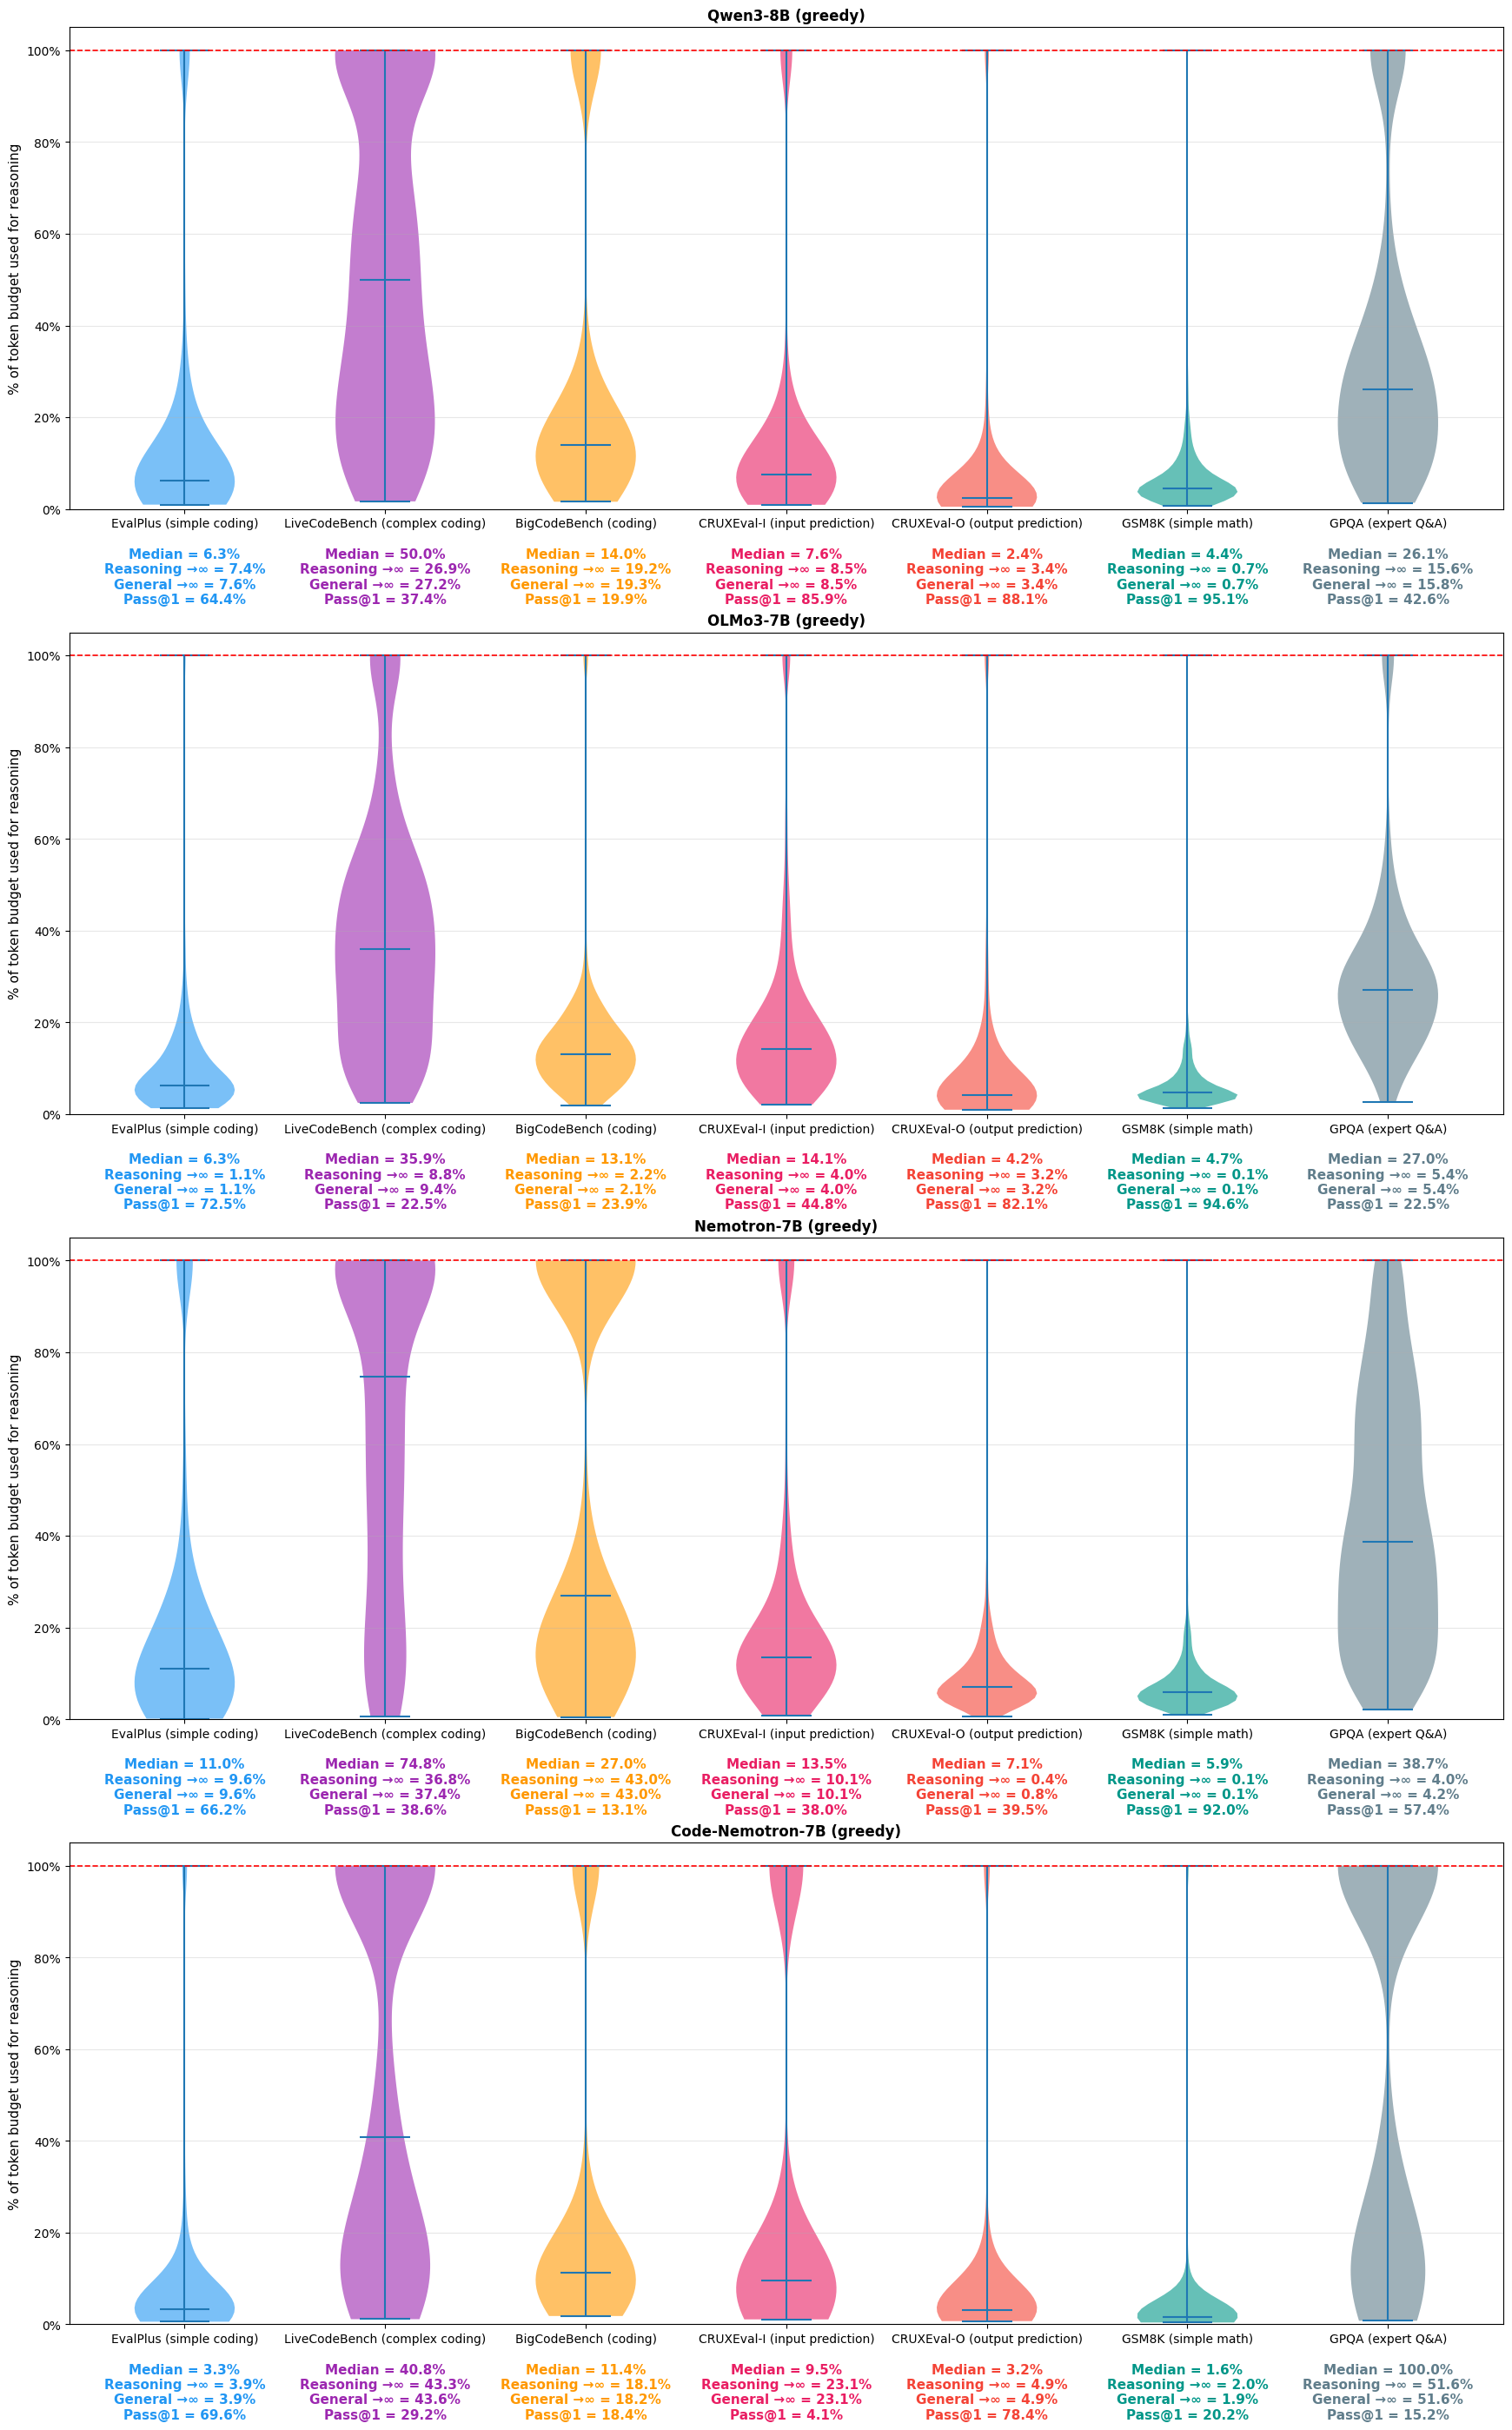

In [19]:
# --- base model comparison: Qwen3-8B vs OLMo3-7B vs Nemotron-7B vs Code-Nemotron-7B, all greedy ---
# shows how the four base models differ in reasoning length across all datasets.
# group_by="dataset": one subplot per dataset, one violin per model (good for comparing models on a task).
# group_by="model": one subplot per model, one violin per dataset (good for seeing how one model varies).

BASE_SERIES = ["qwen3_greedy", "olmo_greedy", "nemotron_greedy", "code_nemotron_greedy"]

plot_token_lengths(
    series_keys=BASE_SERIES,
    loaded_results=all_results,
    datasets=DATASETS,
    group_by="model",
    save_path=FIGURES_DIR / "base_reasoning_token_length.png",
)

plot_budget_pct(
    series_keys=BASE_SERIES,
    loaded_results=all_results,
    datasets=DATASETS,
    group_by="model",
    save_path=FIGURES_DIR / "base_reasoning_budget_pct.png",
)

saved ../../figures/overflow/01/qwen3_steer_reasoning_token_length.png


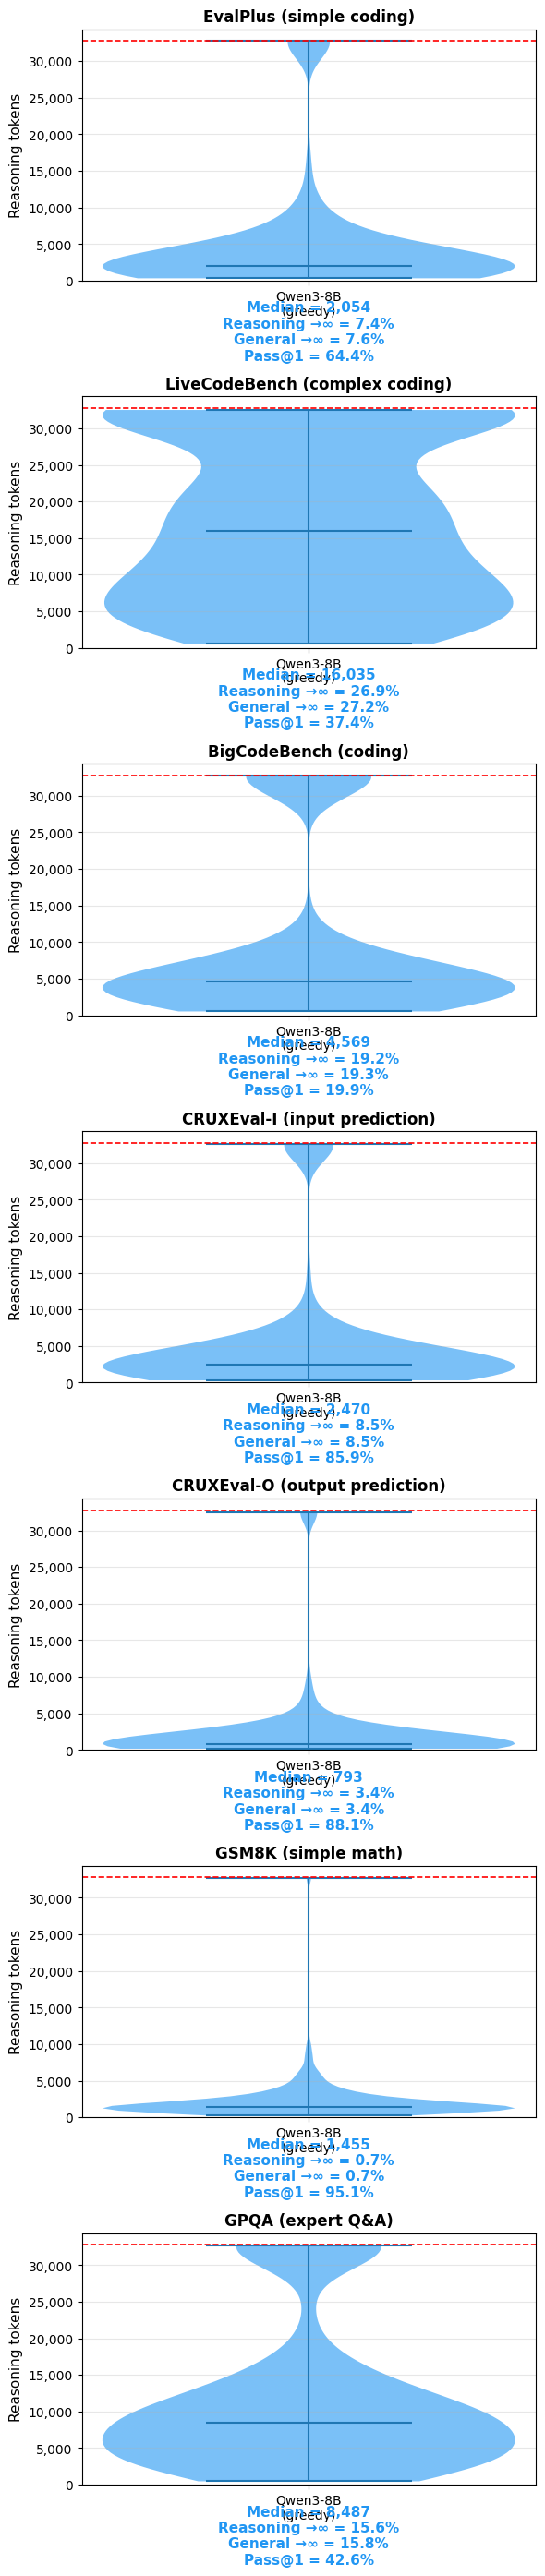

saved ../../figures/overflow/01/qwen3_steer_reasoning_budget_pct.png


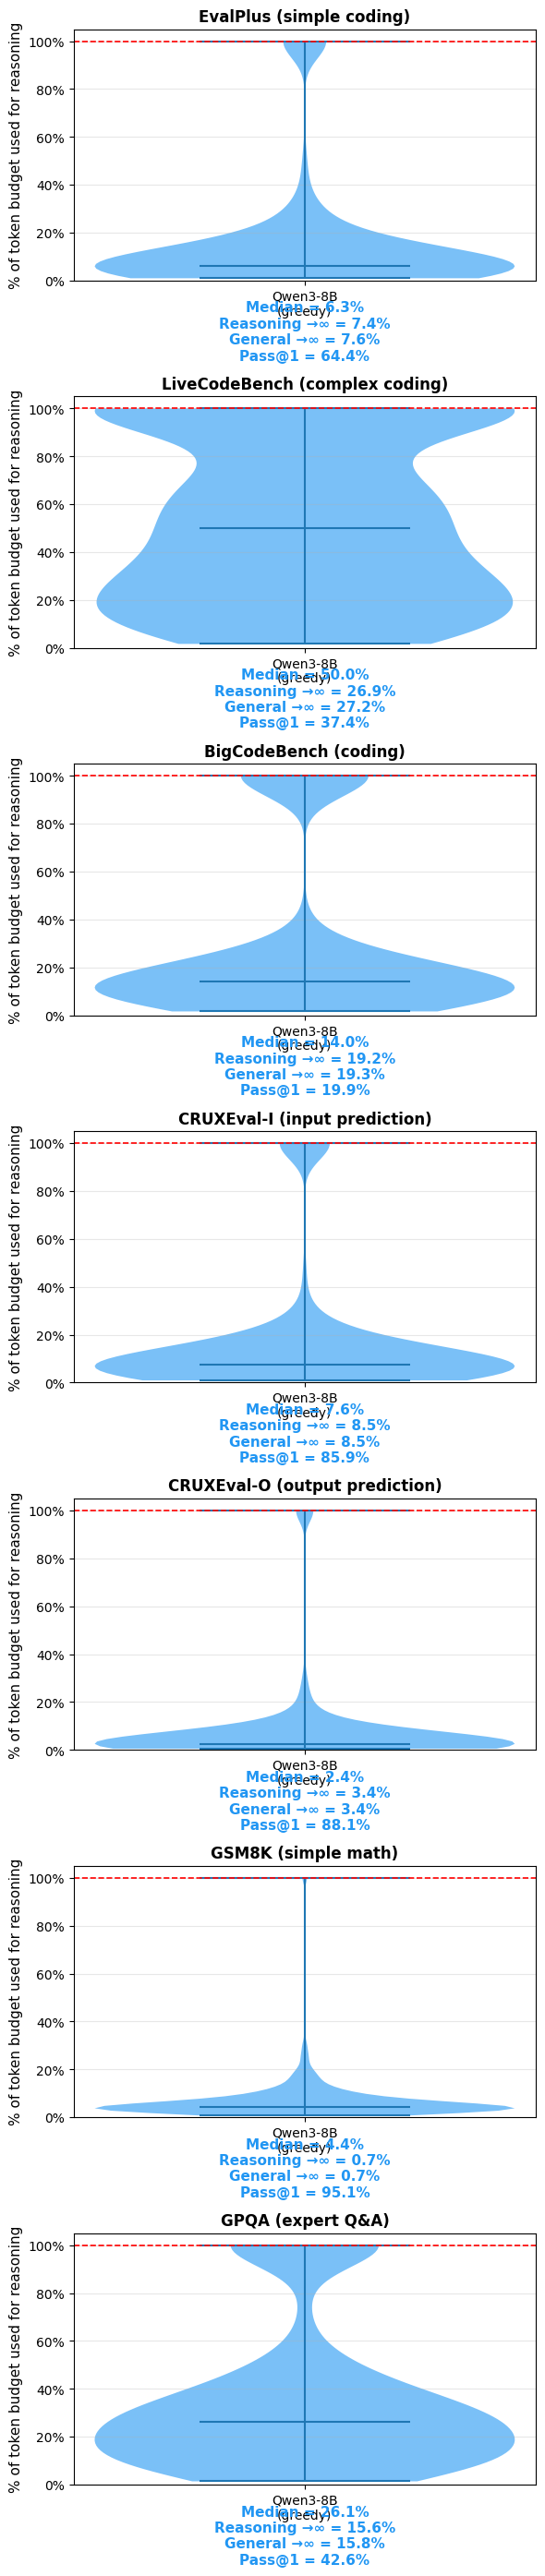

In [18]:
# --- steer comparison: greedy vs steer decoding for Qwen3-8B ---
# steer injects a thought-steering primer after <think> to encourage concise
# step-by-step reasoning; this shows whether it affects reasoning length

STEER_SERIES = ["qwen3_greedy", "qwen3_steer"]

plot_token_lengths(
    series_keys=STEER_SERIES,
    loaded_results=all_results,
    datasets=DATASETS,
    group_by="dataset",
    save_path=FIGURES_DIR / "qwen3_steer_reasoning_token_length.png",
)

plot_budget_pct(
    series_keys=STEER_SERIES,
    loaded_results=all_results,
    datasets=DATASETS,
    group_by="dataset",
    save_path=FIGURES_DIR / "qwen3_steer_reasoning_budget_pct.png",
)